# 📈 04 — Model Evaluation
### Data Flow
```
data/02_test.csv + outputs/best_model.pth → metrics + plots
```


In [1]:

import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')
import os, torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve
from src.model import CreditRiskDNN

os.makedirs('plots', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)


## 1. Load Test Data + Model

In [2]:

df_test       = pd.read_csv('../data/02_test.csv')
feature_names = [c for c in df_test.columns if c != 'DEFAULT']
X_test        = df_test[feature_names].values.astype(np.float32)
y_test        = df_test['DEFAULT'].values.astype(int)

model = CreditRiskDNN(n_features=len(feature_names))
model.load_state_dict(torch.load('../outputs/best_model.pth', map_location='cpu'))
model.eval()

with torch.no_grad():
    logits, attn = model(torch.tensor(X_test))
    probs = torch.sigmoid(logits).numpy().flatten()

preds_04 = (probs >= 0.4).astype(int)

print(f"Test samples  : {len(y_test):,}")
print(f"ROC-AUC       : {roc_auc_score(y_test, probs):.4f}")
print(f"Avg Precision : {average_precision_score(y_test, probs):.4f}")
print(f"Brier Score   : {brier_score_loss(y_test, probs):.4f}")
print(f"Log Loss      : {log_loss(y_test, probs):.4f}")


Test samples  : 6,542
ROC-AUC       : 0.8081
Avg Precision : 0.6476
Brier Score   : 0.1695
Log Loss      : 0.5122


## 2. ROC + Precision-Recall Curves

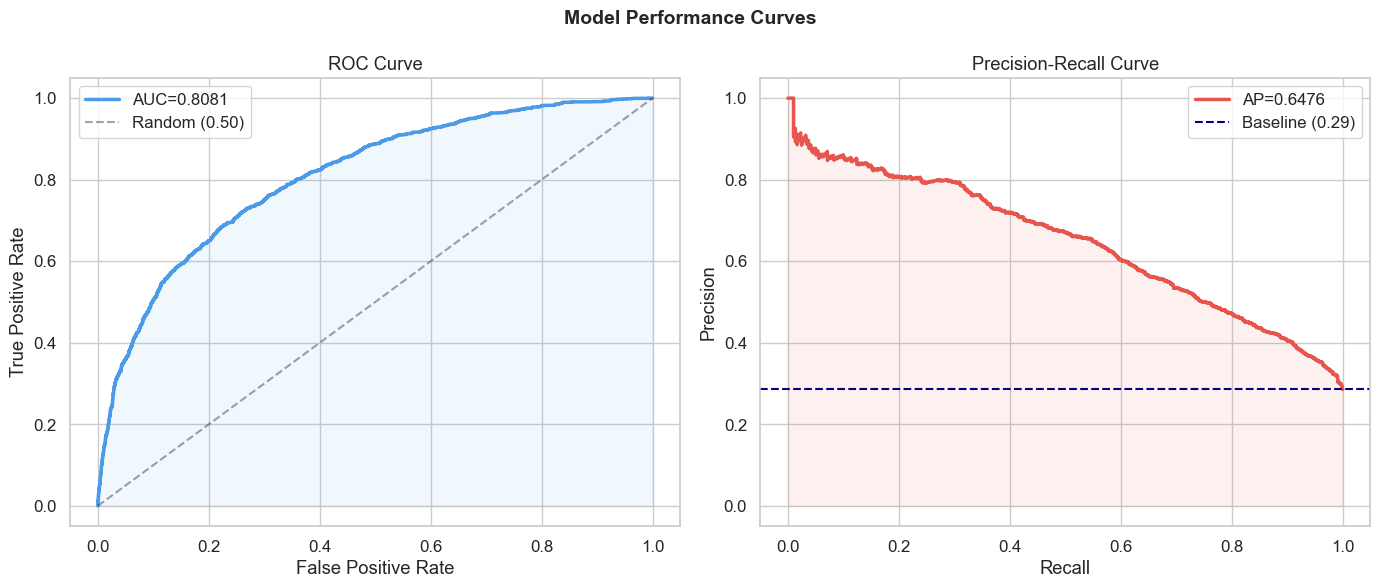

In [3]:

fpr, tpr, roc_thresh = roc_curve(y_test, probs)
auc_score = roc_auc_score(y_test, probs)
precision, recall, _ = precision_recall_curve(y_test, probs)
ap_score  = average_precision_score(y_test, probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')

# ROC
axes[0].plot(fpr, tpr, color='#4C9BE8', linewidth=2.5, label=f'AUC={auc_score:.4f}')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#4C9BE8')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random (0.50)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

# PR
axes[1].plot(recall, precision, color='#E8554C', linewidth=2.5, label=f'AP={ap_score:.4f}')
axes[1].fill_between(recall, precision, alpha=0.08, color='#E8554C')
axes[1].axhline(y_test.mean(), color='navy', linestyle='--',
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig('plots/04_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Threshold Analysis

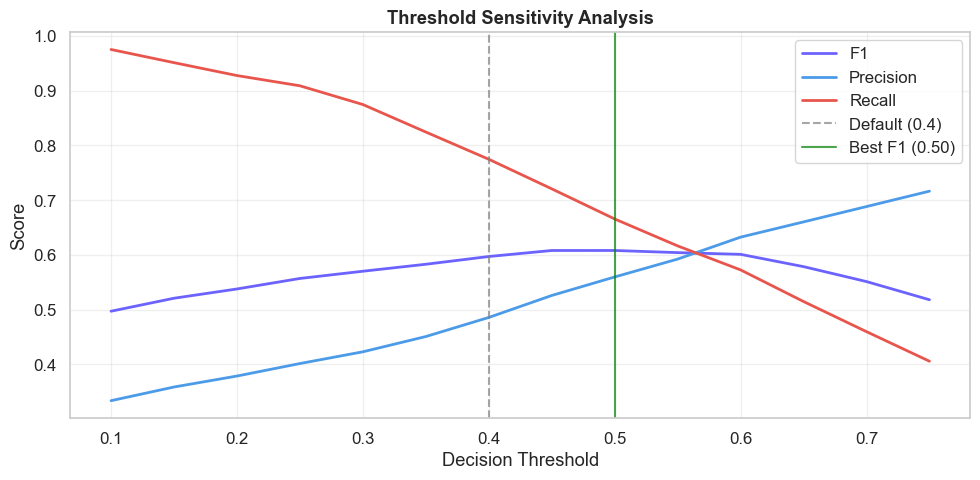

Best F1 threshold: 0.50 → F1=0.6080


In [4]:

thresholds = np.arange(0.1, 0.8, 0.05)
f1s  = [f1_score(y_test, (probs>=t).astype(int), zero_division=0) for t in thresholds]
prcs = [precision_score(y_test, (probs>=t).astype(int), zero_division=0) for t in thresholds]
recs = [recall_score(y_test,    (probs>=t).astype(int), zero_division=0) for t in thresholds]
best_t = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1s,  label='F1',       color='#6C63FF', linewidth=2)
ax.plot(thresholds, prcs, label='Precision', color='#4C9BE8', linewidth=2)
ax.plot(thresholds, recs, label='Recall',    color='#E8554C', linewidth=2)
ax.axvline(0.4,    color='gray',  linestyle='--', alpha=0.7, label='Default (0.4)')
ax.axvline(best_t, color='green', linestyle='-',  alpha=0.7, label=f'Best F1 ({best_t:.2f})')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity Analysis', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/04_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best F1 threshold: {best_t:.2f} → F1={max(f1s):.4f}")


## 4. Confusion Matrices

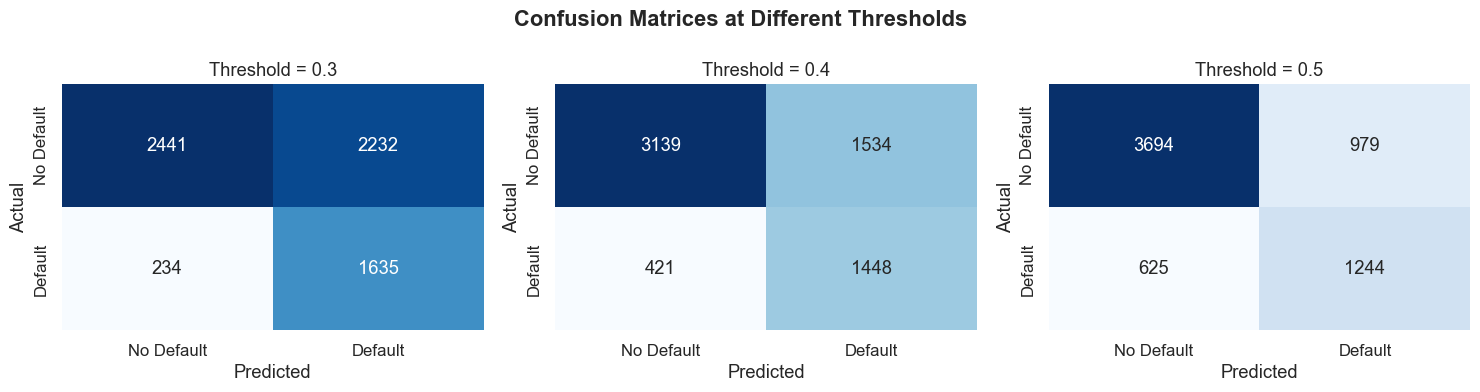

In [5]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices at Different Thresholds', fontweight='bold')

for ax, t in zip(axes, [0.3, 0.4, 0.5]):
    cm = confusion_matrix(y_test, (probs>=t).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default','Default'],
                yticklabels=['No Default','Default'], cbar=False)
    ax.set_title(f'Threshold = {t}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('plots/04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Classification Report

In [6]:

print(classification_report(y_test, preds_04,
                             target_names=['No Default', 'Default']))


              precision    recall  f1-score   support

  No Default       0.88      0.67      0.76      4673
     Default       0.49      0.77      0.60      1869

    accuracy                           0.70      6542
   macro avg       0.68      0.72      0.68      6542
weighted avg       0.77      0.70      0.72      6542



## 6. Calibration

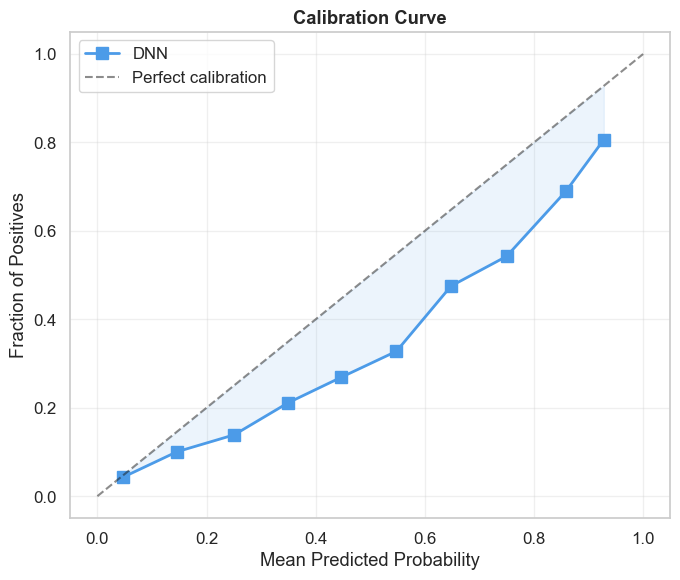

In [7]:

frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, frac_pos, 's-', color='#4C9BE8', linewidth=2,
        markersize=8, label='DNN')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect calibration')
ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.1, color='#4C9BE8')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/04_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
